# 05 — BESS Algorithmic Trading Backtest

This notebook evaluates a simplified forecast-driven trading strategy for the Dutch 50 MW / 100 MWh BESS.

The strategy converts the 24-hour LightGBM price forecast into BUY / SELL / WAIT signals and applies the existing BESS operating constraints:

- 50 MW nominal power
- 100 MWh nominal energy capacity
- 10–90 MWh operating SOC range
- 90% round-trip efficiency
- 97% availability
- 15-minute dispatch intervals
- 100 MWh maximum daily discharge
- Initial SOC of 10 MWh

The backtest is intentionally simplified and is not intended to represent a production trading system.

The forecast-based strategy is compared with the existing perfect-foresight optimisation benchmark as an upper-bound reference.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

PRICE_FILE = PROCESSED_DIR / "nl_day_ahead_prices_15min_2025-10_to_2026-08.csv"
FORECAST_FILE = RESULTS_DIR / "price_forecast_24h_lightgbm.csv"
BENCHMARK_FILE = RESULTS_DIR / "monthly_bess_arbitrage_full_history.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FREQUENCY_HOURS = 0.25

# Existing BESS assumptions
POWER_MW = 50.0
ENERGY_MWH = 100.0

MIN_SOC_MWH = 10.0
MAX_SOC_MWH = 90.0
INITIAL_SOC_MWH = 10.0

ROUND_TRIP_EFFICIENCY = 0.90
DIRECTIONAL_EFFICIENCY = np.sqrt(ROUND_TRIP_EFFICIENCY)

AVAILABILITY = 0.97
AVAILABLE_POWER_MW = POWER_MW * AVAILABILITY

MAX_DAILY_DISCHARGE_MWH = 100.0

SIGNAL_THRESHOLD_EUR_MWH = 10.0

print("Notebook 5 setup complete")
print(f"Available power: {AVAILABLE_POWER_MW:.2f} MW")
print(f"Directional efficiency: {DIRECTIONAL_EFFICIENCY:.4f}")
print(f"Maximum SOC: {MAX_SOC_MWH:.1f} MWh")
print(f"Minimum SOC: {MIN_SOC_MWH:.1f} MWh")

Notebook 5 setup complete
Available power: 48.50 MW
Directional efficiency: 0.9487
Maximum SOC: 90.0 MWh
Minimum SOC: 10.0 MWh


In [3]:
forecast = pd.read_csv(FORECAST_FILE)
prices = pd.read_csv(PRICE_FILE)

forecast["origin_timestamp"] = pd.to_datetime(
    forecast["origin_timestamp"],
    utc=True
)

prices["timestamp_utc"] = pd.to_datetime(
    prices["timestamp_utc"],
    utc=True
)

print("Forecast data:", forecast.shape)
print("Price data:", prices.shape)

print("\nForecast columns:")
print(forecast.columns.tolist())

Forecast data: (86976, 5)
Price data: (31942, 11)

Forecast columns:
['origin_timestamp', 'forecast_horizon', 'target_price', 'predicted_price', 'naive_price']


In [4]:
PRICE_COL = "day_ahead_price_eur_mwh"

current_prices = prices[
    ["timestamp_utc", PRICE_COL]
].rename(
    columns={PRICE_COL: "current_price"}
)

# Forecasted average over the next 4 hours
next_4h_forecast = (
    forecast[forecast["forecast_horizon"] <= 16]
    .groupby("origin_timestamp")["predicted_price"]
    .mean()
    .rename("forecast_next_4h_mean")
)

backtest = (
    next_4h_forecast
    .to_frame()
    .reset_index()
    .merge(
        current_prices,
        left_on="origin_timestamp",
        right_on="timestamp_utc",
        how="left"
    )
)

backtest["expected_price_change"] = (
    backtest["forecast_next_4h_mean"]
    - backtest["current_price"]
)

backtest["signal"] = np.select(
    [
        backtest["expected_price_change"] >= SIGNAL_THRESHOLD_EUR_MWH,
        backtest["expected_price_change"] <= -SIGNAL_THRESHOLD_EUR_MWH,
    ],
    [
        "BUY",
        "SELL",
    ],
    default="WAIT"
)

backtest = backtest.sort_values("origin_timestamp").reset_index(drop=True)

print("Backtest decision rows:", len(backtest))
print("\nSignal distribution:")
print(backtest["signal"].value_counts())

print("\nFirst decisions:")
print(
    backtest[
        [
            "origin_timestamp",
            "current_price",
            "forecast_next_4h_mean",
            "expected_price_change",
            "signal"
        ]
    ].head(10)
)

Backtest decision rows: 906

Signal distribution:
signal
SELL    454
BUY     272
WAIT    180
Name: count, dtype: int64

First decisions:
           origin_timestamp  current_price  forecast_next_4h_mean  \
0 2026-08-07 14:30:00+00:00          86.34             139.789225   
1 2026-08-07 14:45:00+00:00          99.81             141.485753   
2 2026-08-07 15:00:00+00:00         100.68             146.931890   
3 2026-08-07 15:15:00+00:00         107.89             156.809408   
4 2026-08-07 15:30:00+00:00         120.48             157.561383   
5 2026-08-07 15:45:00+00:00         130.47             165.974027   
6 2026-08-07 16:00:00+00:00         121.31             177.812524   
7 2026-08-07 16:15:00+00:00         138.04             160.465341   
8 2026-08-07 16:30:00+00:00         145.65             169.439935   
9 2026-08-07 16:45:00+00:00         162.09             174.664203   

   expected_price_change signal  
0              53.449225    BUY  
1              41.675753    BUY  
2

In [5]:
BACKTEST_START = backtest["origin_timestamp"].min()
BACKTEST_END = backtest["origin_timestamp"].max()

backtest = backtest[
    (backtest["origin_timestamp"] >= BACKTEST_START)
    & (backtest["origin_timestamp"] <= BACKTEST_END)
].copy()

backtest = backtest.reset_index(drop=True)

print("Backtest period")
print("=" * 50)
print("Start:", BACKTEST_START)
print("End:  ", BACKTEST_END)
print("Rows:", len(backtest))

Backtest period
Start: 2026-08-07 14:30:00+00:00
End:   2026-08-29 11:30:00+00:00
Rows: 906


In [6]:
# Constrained BESS dispatch backtest

soc_mwh = INITIAL_SOC_MWH
daily_discharge_mwh = 0.0
current_day = None

results = []

MAX_INTERVAL_GRID_MWH = AVAILABLE_POWER_MW * FREQUENCY_HOURS

for _, row in backtest.iterrows():

    timestamp = row["origin_timestamp"]
    price = row["current_price"]
    signal = row["signal"]

    day = timestamp.date()

    # Reset daily discharge allowance at the start of each day
    if current_day != day:
        current_day = day
        daily_discharge_mwh = 0.0

    soc_before = soc_mwh
    action = "WAIT"
    grid_energy_mwh = 0.0
    pnl_eur = 0.0

    # -------------------------
    # BUY / CHARGE
    # -------------------------
    if signal == "BUY" and soc_mwh < MAX_SOC_MWH:

        # Grid energy that can be charged this interval
        max_charge_grid_mwh = min(
            MAX_INTERVAL_GRID_MWH,
            (MAX_SOC_MWH - soc_mwh) / DIRECTIONAL_EFFICIENCY
        )

        if max_charge_grid_mwh > 1e-9:
            grid_energy_mwh = max_charge_grid_mwh

            # Charging increases stored energy after efficiency losses
            soc_mwh += (
                grid_energy_mwh * DIRECTIONAL_EFFICIENCY
            )

            pnl_eur = -grid_energy_mwh * price
            action = "CHARGE"

    # -------------------------
    # SELL / DISCHARGE
    # -------------------------
    elif signal == "SELL" and soc_mwh > MIN_SOC_MWH:

        remaining_daily_discharge_mwh = (
            MAX_DAILY_DISCHARGE_MWH
            - daily_discharge_mwh
        )

        # Grid-side discharge is constrained by:
        # 1. available power
        # 2. remaining SOC
        # 3. daily discharge limit
        max_discharge_grid_mwh = min(
            MAX_INTERVAL_GRID_MWH,
            (soc_mwh - MIN_SOC_MWH) * DIRECTIONAL_EFFICIENCY,
            remaining_daily_discharge_mwh
        )

        if max_discharge_grid_mwh > 1e-9:
            grid_energy_mwh = max_discharge_grid_mwh

            # Discharging reduces stored energy by more than
            # the delivered grid energy because of efficiency losses
            soc_mwh -= (
                grid_energy_mwh / DIRECTIONAL_EFFICIENCY
            )

            daily_discharge_mwh += grid_energy_mwh

            pnl_eur = grid_energy_mwh * price
            action = "DISCHARGE"

    # Numerical safety
    soc_mwh = min(
        MAX_SOC_MWH,
        max(MIN_SOC_MWH, soc_mwh)
    )

    results.append({
        "timestamp": timestamp,
        "current_price_eur_mwh": price,
        "signal": signal,
        "action": action,
        "grid_energy_mwh": grid_energy_mwh,
        "soc_before_mwh": soc_before,
        "soc_after_mwh": soc_mwh,
        "daily_discharge_mwh": daily_discharge_mwh,
        "pnl_eur": pnl_eur,
    })

backtest_results = pd.DataFrame(results)

print("BESS backtest completed")
print("=" * 50)

print(f"Rows: {len(backtest_results):,}")
print(f"Initial SOC: {INITIAL_SOC_MWH:.2f} MWh")
print(f"Final SOC:   {backtest_results['soc_after_mwh'].iloc[-1]:.2f} MWh")

print("\nActions:")
print(backtest_results["action"].value_counts())

print("\nTotal grid energy:")
print(
    backtest_results["grid_energy_mwh"]
    .sum()
    .round(2),
    "MWh"
)

print("\nTotal PnL:")
print(
    f"€{backtest_results['pnl_eur'].sum():,.2f}"
)

BESS backtest completed
Rows: 906
Initial SOC: 10.00 MWh
Final SOC:   90.00 MWh

Actions:
action
WAIT         723
CHARGE        96
DISCHARGE     87
Name: count, dtype: int64

Total grid energy:
2097.32 MWh

Total PnL:
€97,768.14


In [7]:
# BESS constraint checks

max_soc_observed = backtest_results["soc_after_mwh"].max()
min_soc_observed = backtest_results["soc_after_mwh"].min()

max_interval_energy = backtest_results["grid_energy_mwh"].max()

daily_discharge = (
    backtest_results
    .assign(date=backtest_results["timestamp"].dt.date)
    .groupby("date")["grid_energy_mwh"]
    .sum()
)

# Only discharge actions count toward the daily discharge limit
daily_discharge = (
    backtest_results
    .assign(
        discharge_mwh=np.where(
            backtest_results["action"] == "DISCHARGE",
            backtest_results["grid_energy_mwh"],
            0.0
        ),
        date=backtest_results["timestamp"].dt.date
    )
    .groupby("date")["discharge_mwh"]
    .sum()
)

print("Constraint checks")
print("=" * 50)

print(
    f"SOC range: {min_soc_observed:.4f} to "
    f"{max_soc_observed:.4f} MWh"
)

print(
    f"Maximum interval energy: "
    f"{max_interval_energy:.4f} MWh"
)

print(
    f"Maximum allowed interval energy: "
    f"{MAX_INTERVAL_GRID_MWH:.4f} MWh"
)

print(
    f"Maximum daily discharge: "
    f"{daily_discharge.max():.4f} MWh"
)

print(
    f"Allowed daily discharge: "
    f"{MAX_DAILY_DISCHARGE_MWH:.4f} MWh"
)

print("\nConstraint violations")

print(
    "SOC lower bound:",
    (backtest_results["soc_after_mwh"] < MIN_SOC_MWH - 1e-6).sum()
)

print(
    "SOC upper bound:",
    (backtest_results["soc_after_mwh"] > MAX_SOC_MWH + 1e-6).sum()
)

print(
    "Power/energy limit:",
    (backtest_results["grid_energy_mwh"] >
     MAX_INTERVAL_GRID_MWH + 1e-6).sum()
)

print(
    "Daily discharge limit:",
    (daily_discharge >
     MAX_DAILY_DISCHARGE_MWH + 1e-6).sum()
)

Constraint checks
SOC range: 10.0000 to 90.0000 MWh
Maximum interval energy: 12.1250 MWh
Maximum allowed interval energy: 12.1250 MWh
Maximum daily discharge: 100.0000 MWh
Allowed daily discharge: 100.0000 MWh

Constraint violations
SOC lower bound: 0
SOC upper bound: 0
Power/energy limit: 0
Daily discharge limit: 0


In [8]:
# Mark-to-market PnL including terminal SOC

last_price = backtest_results["current_price_eur_mwh"].iloc[-1]

initial_soc_mwh = INITIAL_SOC_MWH
final_soc_mwh = backtest_results["soc_after_mwh"].iloc[-1]

# Stored energy above the initial inventory level, converted
# to approximate deliverable grid energy
terminal_inventory_change_mwh = (
    final_soc_mwh - initial_soc_mwh
) * DIRECTIONAL_EFFICIENCY

terminal_inventory_value_eur = (
    terminal_inventory_change_mwh * last_price
)

realized_cash_pnl_eur = backtest_results["pnl_eur"].sum()

economic_pnl_eur = (
    realized_cash_pnl_eur
    + terminal_inventory_value_eur
)

backtest_results["cumulative_cash_pnl_eur"] = (
    backtest_results["pnl_eur"].cumsum()
)

print("Economic PnL including terminal inventory")
print("=" * 50)

print(f"Realized cash PnL:       €{realized_cash_pnl_eur:,.2f}")
print(f"Initial SOC:             {initial_soc_mwh:.2f} MWh")
print(f"Final SOC:               {final_soc_mwh:.2f} MWh")
print(f"Final market price:      €{last_price:.2f}/MWh")
print(
    f"Terminal inventory value: "
    f"€{terminal_inventory_value_eur:,.2f}"
)
print(
    f"\nEconomic PnL:             "
    f"€{economic_pnl_eur:,.2f}"
)

Economic PnL including terminal inventory
Realized cash PnL:       €97,768.14
Initial SOC:             10.00 MWh
Final SOC:               90.00 MWh
Final market price:      €-1.69/MWh
Terminal inventory value: €-128.26

Economic PnL:             €97,639.87


In [9]:
# Backtest performance and risk metrics

daily_pnl = (
    backtest_results
    .assign(
        date=backtest_results["timestamp"].dt.date
    )
    .groupby("date")["pnl_eur"]
    .sum()
)

cumulative_pnl = backtest_results["cumulative_cash_pnl_eur"]

running_max = cumulative_pnl.cummax()
drawdown = cumulative_pnl - running_max

max_drawdown_eur = drawdown.min()

profitable_days = (daily_pnl > 0).sum()
total_days = len(daily_pnl)

daily_pnl_std = daily_pnl.std()

if daily_pnl_std > 0:
    simple_daily_sharpe = (
        daily_pnl.mean() / daily_pnl_std
    )
else:
    simple_daily_sharpe = np.nan

charge_energy_mwh = backtest_results.loc[
    backtest_results["action"] == "CHARGE",
    "grid_energy_mwh"
].sum()

discharge_energy_mwh = backtest_results.loc[
    backtest_results["action"] == "DISCHARGE",
    "grid_energy_mwh"
].sum()

print("Backtest performance")
print("=" * 50)

print(f"Realized cash PnL:       €{realized_cash_pnl_eur:,.2f}")
print(f"Economic PnL:            €{economic_pnl_eur:,.2f}")
print(f"Charge energy:           {charge_energy_mwh:,.2f} MWh")
print(f"Discharge energy:        {discharge_energy_mwh:,.2f} MWh")
print(f"Final SOC:               {final_soc_mwh:.2f} MWh")

print("\nRisk metrics")
print("=" * 50)

print(f"Daily PnL volatility:     €{daily_pnl_std:,.2f}")
print(f"Maximum cash drawdown:   €{max_drawdown_eur:,.2f}")
print(
    f"Profitable days:         "
    f"{profitable_days}/{total_days}"
)
print(
    f"Profitable-day ratio:    "
    f"{profitable_days / total_days:.1%}"
)
print(
    f"Simple daily Sharpe:     "
    f"{simple_daily_sharpe:.3f}"
)

Backtest performance
Realized cash PnL:       €97,768.14
Economic PnL:            €97,639.87
Charge energy:           1,143.80 MWh
Discharge energy:        953.52 MWh
Final SOC:               90.00 MWh

Risk metrics
Daily PnL volatility:     €8,949.58
Maximum cash drawdown:   €-12,678.78
Profitable days:         10/13
Profitable-day ratio:    76.9%
Simple daily Sharpe:     0.840


In [10]:
# Perfect-foresight benchmark

benchmark = pd.read_csv(BENCHMARK_FILE)

print("Benchmark shape:", benchmark.shape)
print("\nBenchmark columns:")
print(benchmark.columns.tolist())

print("\nAvailable months:")
print(benchmark["month"].tolist())

Benchmark shape: (11, 11)

Benchmark columns:
['month', 'intervals', 'total_revenue_eur', 'charging_cost_eur', 'discharge_revenue_eur', 'energy_charged_mwh', 'energy_discharged_mwh', 'efc', 'max_daily_discharge_mwh', 'max_soc_mwh', 'min_soc_mwh']

Available months:
['2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06', '2026-07', '2026-08']


In [11]:
# August 2026 perfect-foresight benchmark

august_benchmark = benchmark[
    benchmark["month"] == "2026-08"
].copy()

if august_benchmark.empty:
    raise ValueError("August 2026 benchmark row not found.")

august_benchmark = august_benchmark.iloc[0]

benchmark_revenue_eur = august_benchmark["total_revenue_eur"]
benchmark_charge_cost_eur = august_benchmark["charging_cost_eur"]
benchmark_discharge_revenue_eur = august_benchmark["discharge_revenue_eur"]

benchmark_charged_mwh = august_benchmark["energy_charged_mwh"]
benchmark_discharged_mwh = august_benchmark["energy_discharged_mwh"]
benchmark_efc = august_benchmark["efc"]

print("August 2026 perfect-foresight benchmark")
print("=" * 50)

print(f"Total revenue:       €{benchmark_revenue_eur:,.2f}")
print(f"Charging cost:       €{benchmark_charge_cost_eur:,.2f}")
print(f"Discharge revenue:   €{benchmark_discharge_revenue_eur:,.2f}")
print(f"Energy charged:      {benchmark_charged_mwh:,.2f} MWh")
print(f"Energy discharged:   {benchmark_discharged_mwh:,.2f} MWh")
print(f"EFC:                  {benchmark_efc:.2f}")
print(f"Maximum daily discharge: {august_benchmark['max_daily_discharge_mwh']:.2f} MWh")
print(f"Maximum SOC:             {august_benchmark['max_soc_mwh']:.2f} MWh")
print(f"Minimum SOC:             {august_benchmark['min_soc_mwh']:.2f} MWh")

August 2026 perfect-foresight benchmark
Total revenue:       €434,396.21
Charging cost:       €174,084.30
Discharge revenue:   €608,480.50
Energy charged:      3,444.44 MWh
Energy discharged:   3,100.00 MWh
EFC:                  31.00
Maximum daily discharge: 100.00 MWh
Maximum SOC:             90.00 MWh
Minimum SOC:             10.00 MWh


In [12]:
# Strategy vs perfect foresight comparison

strategy_pnl_eur = economic_pnl_eur

comparison = pd.DataFrame({
    "metric": [
        "Test / benchmark coverage",
        "Economic PnL / revenue",
        "Energy charged (MWh)",
        "Energy discharged (MWh)",
        "Final SOC (MWh)",
    ],
    "forecast_strategy": [
        f"{BACKTEST_START} to {BACKTEST_END}",
        strategy_pnl_eur,
        charge_energy_mwh,
        discharge_energy_mwh,
        final_soc_mwh,
    ],
    "perfect_foresight": [
        "Full August 2026",
        benchmark_revenue_eur,
        benchmark_charged_mwh,
        benchmark_discharged_mwh,
        august_benchmark["min_soc_mwh"],
    ],
})

print(comparison.to_string(index=False))

                   metric                                      forecast_strategy perfect_foresight
Test / benchmark coverage 2026-08-07 14:30:00+00:00 to 2026-08-29 11:30:00+00:00  Full August 2026
   Economic PnL / revenue                                           97639.874249     434396.205258
     Energy charged (MWh)                                            1143.795891       3444.444444
  Energy discharged (MWh)                                             953.521638            3100.0
          Final SOC (MWh)                                                   90.0              10.0


In [13]:
# Save algorithmic trading backtest results

BACKTEST_FILE = RESULTS_DIR / "bess_algorithmic_trading_backtest.csv"
SUMMARY_FILE = RESULTS_DIR / "bess_algorithmic_trading_summary.csv"

backtest_results.to_csv(
    BACKTEST_FILE,
    index=False
)

summary = pd.DataFrame({
    "metric": [
        "backtest_start",
        "backtest_end",
        "forecast_origins",
        "realized_cash_pnl_eur",
        "economic_pnl_eur",
        "charge_energy_mwh",
        "discharge_energy_mwh",
        "initial_soc_mwh",
        "final_soc_mwh",
        "daily_pnl_volatility_eur",
        "max_cash_drawdown_eur",
        "profitable_days",
        "total_days",
        "profitable_day_ratio",
        "simple_daily_sharpe",
        "perfect_foresight_august_revenue_eur",
    ],
    "value": [
        str(BACKTEST_START),
        str(BACKTEST_END),
        len(backtest_results),
        realized_cash_pnl_eur,
        economic_pnl_eur,
        charge_energy_mwh,
        discharge_energy_mwh,
        INITIAL_SOC_MWH,
        final_soc_mwh,
        daily_pnl_std,
        max_drawdown_eur,
        profitable_days,
        total_days,
        profitable_days / total_days,
        simple_daily_sharpe,
        benchmark_revenue_eur,
    ],
})

summary.to_csv(
    SUMMARY_FILE,
    index=False
)

print("Saved:")
print(BACKTEST_FILE)
print(SUMMARY_FILE)

Saved:
C:\Users\USER\dutch-bess-flexibility-commercial-value-intelligence\results\bess_algorithmic_trading_backtest.csv
C:\Users\USER\dutch-bess-flexibility-commercial-value-intelligence\results\bess_algorithmic_trading_summary.csv


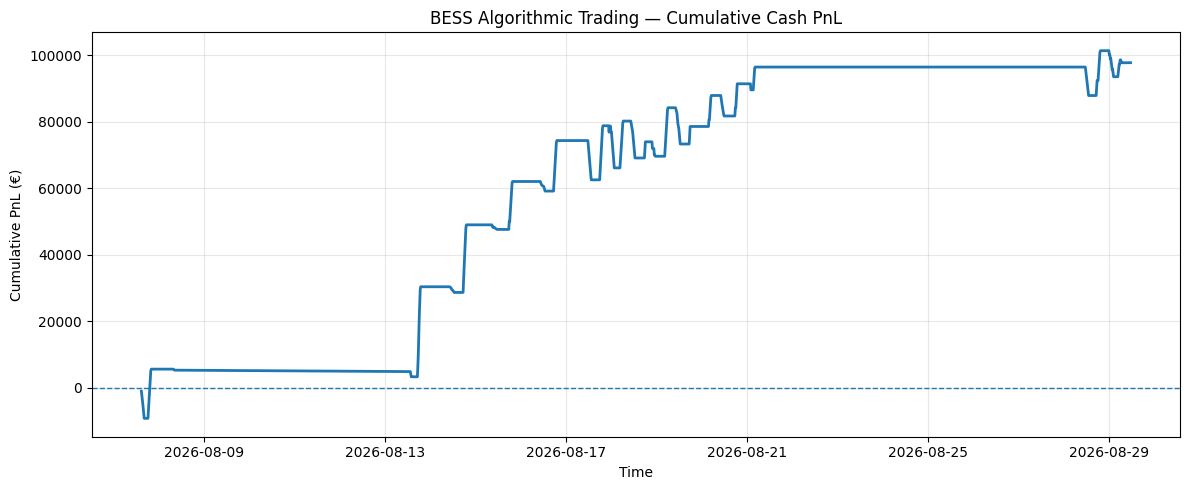

In [14]:
# Cumulative cash PnL

plt.figure(figsize=(12, 5))

plt.plot(
    backtest_results["timestamp"],
    backtest_results["cumulative_cash_pnl_eur"],
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("BESS Algorithmic Trading — Cumulative Cash PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL (€)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

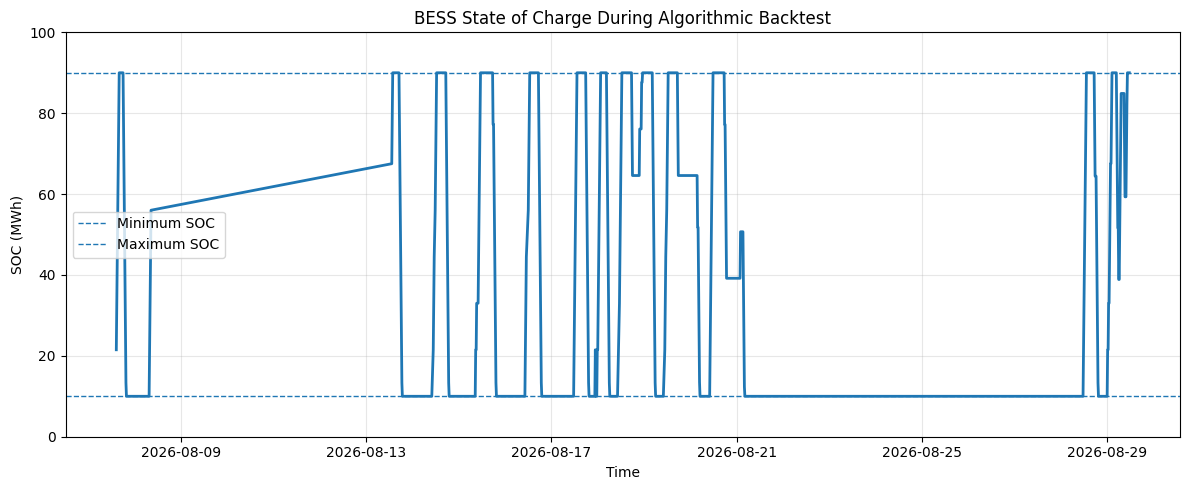

In [15]:
# BESS SOC trajectory

plt.figure(figsize=(12, 5))

plt.plot(
    backtest_results["timestamp"],
    backtest_results["soc_after_mwh"],
    linewidth=2
)

plt.axhline(
    MIN_SOC_MWH,
    linestyle="--",
    linewidth=1,
    label="Minimum SOC"
)

plt.axhline(
    MAX_SOC_MWH,
    linestyle="--",
    linewidth=1,
    label="Maximum SOC"
)

plt.title("BESS State of Charge During Algorithmic Backtest")
plt.xlabel("Time")
plt.ylabel("SOC (MWh)")
plt.ylim(0, ENERGY_MWH)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [16]:
# Final KPI summary

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Recalculate forecasting metrics from the saved test forecasts
forecast_rmse = np.sqrt(
    mean_squared_error(
        forecast["target_price"],
        forecast["predicted_price"]
    )
)

forecast_mae = mean_absolute_error(
    forecast["target_price"],
    forecast["predicted_price"]
)

naive_rmse = np.sqrt(
    mean_squared_error(
        forecast["target_price"],
        forecast["naive_price"]
    )
)

naive_mae = mean_absolute_error(
    forecast["target_price"],
    forecast["naive_price"]
)

forecast_rmse_improvement = (
    1 - forecast_rmse / naive_rmse
)

forecast_mae_improvement = (
    1 - forecast_mae / naive_mae
)

final_kpis = pd.DataFrame({
    "KPI": [
        "Forecast RMSE (€/MWh)",
        "Forecast MAE (€/MWh)",
        "RMSE improvement vs persistence",
        "MAE improvement vs persistence",
        "Backtest start",
        "Backtest end",
        "Trading decision intervals",
        "Realized cash PnL (€)",
        "Economic PnL (€)",
        "Energy charged (MWh)",
        "Energy discharged (MWh)",
        "Initial SOC (MWh)",
        "Final SOC (MWh)",
        "Maximum cash drawdown (€)",
        "Profitable days",
        "Profitable-day ratio",
        "Simple daily Sharpe",
        "August perfect-foresight benchmark (€)"
    ],
    "Value": [
        forecast_rmse,
        forecast_mae,
        forecast_rmse_improvement,
        forecast_mae_improvement,
        str(BACKTEST_START),
        str(BACKTEST_END),
        len(backtest_results),
        realized_cash_pnl_eur,
        economic_pnl_eur,
        charge_energy_mwh,
        discharge_energy_mwh,
        INITIAL_SOC_MWH,
        final_soc_mwh,
        max_drawdown_eur,
        f"{profitable_days}/{total_days}",
        profitable_days / total_days,
        simple_daily_sharpe,
        benchmark_revenue_eur
    ]
})

print(final_kpis.to_string(index=False))

                                   KPI                     Value
                 Forecast RMSE (€/MWh)                 42.235344
                  Forecast MAE (€/MWh)                 31.195713
       RMSE improvement vs persistence                  0.417897
        MAE improvement vs persistence                  0.396951
                        Backtest start 2026-08-07 14:30:00+00:00
                          Backtest end 2026-08-29 11:30:00+00:00
            Trading decision intervals                       906
                 Realized cash PnL (€)              97768.136231
                      Economic PnL (€)              97639.874249
                  Energy charged (MWh)               1143.795891
               Energy discharged (MWh)                953.521638
                     Initial SOC (MWh)                      10.0
                       Final SOC (MWh)                      90.0
             Maximum cash drawdown (€)              -12678.78289
                       Pr

In [16]:
FINAL_KPI_FILE = RESULTS_DIR / "bess_algorithmic_trading_final_kpis.csv"

final_kpis.to_csv(
    FINAL_KPI_FILE,
    index=False
)

print(f"\nFinal KPI file saved:")
print(FINAL_KPI_FILE)


Final KPI file saved:
C:\Users\USER\dutch-bess-flexibility-commercial-value-intelligence\results\bess_algorithmic_trading_final_kpis.csv
